In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import torch

WORLD_SIZE = 32
torch.manual_seed(0)

OPS = ("all_reduce", "reduce_scatter", "all_gather")

class CommLog:
    """Counts collective calls and bytes sent per rank (ring cost model)."""
    def __init__(self):
        self.reset()

    def reset(self):
        self.calls = {op: 0 for op in OPS}
        self.bytes = {op: 0.0 for op in OPS}

    def record(self, op, nbytes):
        self.calls[op] += 1
        self.bytes[op] += nbytes

    def total_bytes(self):
        return sum(self.bytes.values())

    def summary(self):
        for op in OPS:
            print(f"{op:15s} calls={self.calls[op]:4d}  MB/rank={self.bytes[op]/1e6:9.3f}")
        print(f"{'total':15s}             MB/rank={self.total_bytes()/1e6:9.3f}")

In [3]:
def nbytes(t):
    return t.numel() * t.element_size()

def pad_to_multiple(flat, n):
    """Pad a 1-D tensor with zeros so its length divides evenly by n."""
    pad = (-flat.numel()) % n
    return torch.cat([flat, flat.new_zeros(pad)]), pad

def all_reduce(tensors, log):
    """Every rank ends with the mean of all ranks' tensors."""
    n = len(tensors)
    mean = torch.stack(tensors).mean(0)
    log.record("all_reduce", 2 * (n - 1) / n * nbytes(tensors[0]))
    return [mean.clone() for _ in range(n)]

def reduce_scatter(tensors, log):
    """Average full 1-D tensors across ranks; rank r keeps only shard r."""
    n = len(tensors)
    assert tensors[0].dim() == 1 and tensors[0].numel() % n == 0, "flatten + pad first"
    mean = torch.stack(tensors).mean(0)
    log.record("reduce_scatter", (n - 1) / n * nbytes(tensors[0]))
    return [s.clone() for s in mean.chunk(n)]

def all_gather(shards, log):
    """Each rank holds shard r; every rank ends with the full concatenation."""
    n = len(shards)
    full = torch.cat(shards)
    log.record("all_gather", (n - 1) / n * nbytes(full))
    return [full.clone() for _ in range(n)]

In [4]:
log = CommLog()
N = WORLD_SIZE
xs = [torch.randn(N * 1000) for _ in range(N)]   # one full tensor per rank

ar = all_reduce(xs, log)
rs_ag = all_gather(reduce_scatter(xs, log), log)

# 1. All-reduce result is identical on every rank
assert all(torch.equal(ar[0], t) for t in ar)
# 2. Reduce-scatter + all-gather gives the same result as all-reduce
assert all(torch.allclose(a, b) for a, b in zip(ar, rs_ag))
# 3. ...and costs the same bytes
assert abs(log.bytes["all_reduce"]
           - log.bytes["reduce_scatter"] - log.bytes["all_gather"]) < 1e-6
# 4. Padding round-trips
p, pad = pad_to_multiple(torch.randn(1001), N)
assert p.numel() % N == 0 and pad == (-1001) % N

log.summary()
print("Stage 1 checks passed.")

all_reduce      calls=   1  MB/rank=    0.248
reduce_scatter  calls=   1  MB/rank=    0.124
all_gather      calls=   1  MB/rank=    0.124
total                       MB/rank=    0.496
Stage 1 checks passed.


In [5]:
import torch.nn as nn
import torch.nn.functional as F

IN_DIM, HID, OUT_DIM, N_HIDDEN = 256, 384, 10, 6
MICRO_BATCH = 16

def make_model():
    dims = [IN_DIM] + [HID] * N_HIDDEN + [HID]
    layers = []
    for a, b in zip(dims[:-1], dims[1:]):
        layers += [nn.Linear(a, b), nn.ReLU()]
    layers.append(nn.Linear(HID, OUT_DIM))
    return nn.Sequential(*layers)

torch.manual_seed(0)
model = make_model()
P = sum(p.numel() for p in model.parameters())
print(f"params: {P:,}  ({P * 16 / 1e6:.1f} MB/rank at 16 bytes/param)")

# Synthetic data: one micro-batch per rank, fixed for all modes
g = torch.Generator().manual_seed(1)
BATCHES = [(torch.randn(MICRO_BATCH, IN_DIM, generator=g),
            torch.randint(0, OUT_DIM, (MICRO_BATCH,), generator=g))
           for _ in range(WORLD_SIZE)]

params: 989,578  (15.8 MB/rank at 16 bytes/param)


In [6]:
SHAPES  = [p.shape for p in model.parameters()]
NUMELS  = [p.numel() for p in model.parameters()]
OFFSETS = [sum(NUMELS[:i]) for i in range(len(NUMELS) + 1)]

def get_flat_params(m):
    return torch.cat([p.detach().reshape(-1) for p in m.parameters()])

def set_flat_params(m, flat):
    with torch.no_grad():
        for p, lo, hi in zip(m.parameters(), OFFSETS[:-1], OFFSETS[1:]):
            p.copy_(flat[lo:hi].view(p.shape))

def get_flat_grads(m):
    return torch.cat([(p.grad if p.grad is not None
                       else torch.zeros_like(p)).reshape(-1)
                      for p in m.parameters()])

def compute_grad(m, flat_params, x, y):
    """Forward + backward for one micro-batch. Returns (flat grad, loss)."""
    set_flat_params(m, flat_params)
    m.zero_grad(set_to_none=True)
    loss = F.cross_entropy(m(x), y)
    loss.backward()
    return get_flat_grads(m), loss.item()

def adam_step(w, grad, m_s, v_s, t, lr=1e-3, b1=0.9, b2=0.999, eps=1e-8):
    """In-place Adam on any 1-D slice. Same function for full vector or shard."""
    m_s.mul_(b1).add_(grad, alpha=1 - b1)
    v_s.mul_(b2).addcmul_(grad, grad, value=1 - b2)
    mhat = m_s / (1 - b1 ** t)
    vhat = v_s / (1 - b2 ** t)
    w.addcdiv_(mhat, vhat.sqrt().add_(eps), value=-lr)

In [7]:
ELEM = 4  # fp32 bytes

def mem_bytes(mode, P, N):
    """Steady-state bytes held per rank, by category."""
    full, shard = P, P / N
    w, gr, opt = {
        "ddp":   (full,  full,  2 * full),
        "zero1": (full,  full,  2 * shard),
        "zero2": (full,  shard, 2 * shard),
        "zero3": (shard, shard, 2 * shard),
    }[mode]
    d = {"weights": w * ELEM, "grads": gr * ELEM, "optim": opt * ELEM}
    d["total"] = sum(d.values())
    return d

for mode in ("ddp", "zero1", "zero2", "zero3"):
    d = mem_bytes(mode, P, WORLD_SIZE)
    print(f"{mode:6s} {d['total']/1e6:7.2f} MB/rank "
          f"({d['total']/P:5.2f} bytes/param)")

ddp      15.83 MB/rank (16.00 bytes/param)
zero1     8.16 MB/rank ( 8.25 bytes/param)
zero2     4.33 MB/rank ( 4.38 bytes/param)
zero3     0.49 MB/rank ( 0.50 bytes/param)


In [13]:
STEPS = 20

def train_ddp(steps=STEPS, N=WORLD_SIZE, verbose=True):
    torch.manual_seed(0)
    m = make_model()
    w, PAD = pad_to_multiple(get_flat_params(m), N)                  # replicated on every rank
    exp_avg, exp_avg_sq = torch.zeros_like(w), torch.zeros_like(w)
    log = CommLog()
    losses = []

    for t in range(1, steps + 1):
        # Each rank: forward/backward on its own micro-batch
        grads, step_loss = [], 0.0
        for r in range(N):
            gr, l = compute_grad(m, w[:P], *BATCHES[r])
            grads.append(torch.cat([gr, gr.new_zeros(PAD)]))
            step_loss += l / N

        # All-reduce: every rank ends with the averaged full gradient
        grads = all_reduce(grads, log)

        # Every rank runs the identical full Adam update (redundant work)
        adam_step(w, grads[0], exp_avg, exp_avg_sq, t)
        losses.append(step_loss)
        if verbose and (t == 1 or t % 5 == 0):
            print(f"step {t:3d}  loss {step_loss:.4f}")

    return {"w": w[:P], "losses": losses, "log": log,
            "mem": mem_bytes("ddp", P, N)}

ddp = train_ddp()
REFERENCE_W = ddp["w"].clone()   # ZeRO-1/2/3 must match this exactly

print()
ddp["log"].summary()
print(f"\nloss {ddp['losses'][0]:.4f} -> {ddp['losses'][-1]:.4f}")

step   1  loss 2.3039
step   5  loss 2.2855
step  10  loss 2.0354
step  15  loss 1.6168
step  20  loss 0.8601

all_reduce      calls=  20  MB/rank=  153.388
reduce_scatter  calls=   0  MB/rank=    0.000
all_gather      calls=   0  MB/rank=    0.000
total                       MB/rank=  153.388

loss 2.3039 -> 0.8601


In [14]:
def train_zero1(steps=STEPS, N=WORLD_SIZE, verbose=True):
    torch.manual_seed(0)
    m = make_model()
    w, PAD = pad_to_multiple(get_flat_params(m), N)
    S = w.numel() // N                      # shard length

    # Each rank holds Adam state for its shard only
    exp_avg    = [torch.zeros(S) for _ in range(N)]
    exp_avg_sq = [torch.zeros(S) for _ in range(N)]

    log, losses = CommLog(), []

    for t in range(1, steps + 1):
        # 1. Forward/backward — full weights, same as DDP
        grads, step_loss = [], 0.0
        for r in range(N):
            gr, l = compute_grad(m, w[:P], *BATCHES[r])
            grads.append(torch.cat([gr, gr.new_zeros(PAD)]))
            step_loss += l / N

        # 2. All-reduce: every rank gets the full averaged gradient
        grads = all_reduce(grads, log)

        # 3. Each rank updates ONLY its own shard of the weights
        shards = list(w.chunk(N))
        for r in range(N):
            adam_step(shards[r], grads[r].chunk(N)[r],
                      exp_avg[r], exp_avg_sq[r], t)

        # 4. All-gather: reassemble full weights on every rank
        w = all_gather([s.clone() for s in shards], log)[0]

        losses.append(step_loss)
        if verbose and (t == 1 or t % 5 == 0):
            print(f"step {t:3d}  loss {step_loss:.4f}")

    return {"w": w[:P], "losses": losses, "log": log,
            "mem": mem_bytes("zero1", P, N), "pad": PAD}

In [15]:
z1 = train_zero1()

print()
z1["log"].summary()

max_diff = (z1["w"] - REFERENCE_W).abs().max().item()
print(f"\nmax |ZeRO-1 - DDP| = {max_diff:.3e}")
assert torch.equal(z1["w"], REFERENCE_W), "ZeRO-1 diverged from DDP"
assert z1["losses"] == ddp["losses"], "loss curves differ"
print("ZeRO-1 matches DDP exactly.")

print(f"\nmem:  {ddp['mem']['total']/1e6:6.2f} -> "
      f"{z1['mem']['total']/1e6:6.2f} MB/rank")
print(f"comm: {ddp['log'].total_bytes()/1e6:6.2f} -> "
      f"{z1['log'].total_bytes()/1e6:6.2f} MB/rank "
      f"({z1['log'].total_bytes()/ddp['log'].total_bytes():.2f}x)")

step   1  loss 2.3039
step   5  loss 2.2855
step  10  loss 2.0354
step  15  loss 1.6168
step  20  loss 0.8601

all_reduce      calls=  20  MB/rank=  153.388
reduce_scatter  calls=   0  MB/rank=    0.000
all_gather      calls=  20  MB/rank=   76.694
total                       MB/rank=  230.082

max |ZeRO-1 - DDP| = 0.000e+00
ZeRO-1 matches DDP exactly.

mem:   15.83 ->   8.16 MB/rank
comm: 153.39 -> 230.08 MB/rank (1.50x)


In [16]:
def train_zero2(steps=STEPS, N=WORLD_SIZE, verbose=True):
    torch.manual_seed(0)
    m = make_model()
    w, PAD = pad_to_multiple(get_flat_params(m), N)
    S = w.numel() // N

    exp_avg    = [torch.zeros(S) for _ in range(N)]
    exp_avg_sq = [torch.zeros(S) for _ in range(N)]

    log, losses = CommLog(), []

    for t in range(1, steps + 1):
        # 1. Forward/backward — full weights, same as DDP and ZeRO-1
        grads, step_loss = [], 0.0
        for r in range(N):
            gr, l = compute_grad(m, w[:P], *BATCHES[r])
            grads.append(torch.cat([gr, gr.new_zeros(PAD)]))
            step_loss += l / N

        # 2. Reduce-scatter: rank r keeps ONLY its averaged gradient shard.
        #    Half the bytes of an all-reduce; the rest is freed.
        g_shards = reduce_scatter(grads, log)
        del grads

        # 3. Each rank updates its own weight shard
        shards = list(w.chunk(N))
        for r in range(N):
            adam_step(shards[r], g_shards[r], exp_avg[r], exp_avg_sq[r], t)

        # 4. All-gather the weights — unchanged from ZeRO-1
        w = all_gather([s.clone() for s in shards], log)[0]

        losses.append(step_loss)
        if verbose and (t == 1 or t % 5 == 0):
            print(f"step {t:3d}  loss {step_loss:.4f}")

    return {"w": w[:P], "losses": losses, "log": log,
            "mem": mem_bytes("zero2", P, N), "pad": PAD}

In [17]:
z2 = train_zero2()

print()
z2["log"].summary()

print(f"\nmax |ZeRO-2 - DDP| = "
      f"{(z2['w'] - REFERENCE_W).abs().max().item():.3e}")
assert torch.equal(z2["w"], REFERENCE_W), "ZeRO-2 diverged from DDP"
print("ZeRO-2 matches DDP exactly.")

print(f"\n{'mode':8s} {'MB/rank':>9s} {'B/param':>8s} {'comm MB':>9s} {'vs DDP':>7s} {'calls':>6s}")
for name, run in (("ddp", ddp), ("zero1", z1), ("zero2", z2)):
    mb, cb = run["mem"]["total"], run["log"].total_bytes()
    print(f"{name:8s} {mb/1e6:9.2f} {mb/P:8.2f} {cb/1e6:9.2f} "
          f"{cb/ddp['log'].total_bytes():6.2f}x "
          f"{sum(run['log'].calls.values()):6d}")

step   1  loss 2.3039
step   5  loss 2.2855
step  10  loss 2.0354
step  15  loss 1.6168
step  20  loss 0.8601

all_reduce      calls=   0  MB/rank=    0.000
reduce_scatter  calls=  20  MB/rank=   76.694
all_gather      calls=  20  MB/rank=   76.694
total                       MB/rank=  153.388

max |ZeRO-2 - DDP| = 0.000e+00
ZeRO-2 matches DDP exactly.

mode       MB/rank  B/param   comm MB  vs DDP  calls
ddp          15.83    16.00    153.39   1.00x     20
zero1         8.16     8.25    230.08   1.50x     40
zero2         4.33     4.38    153.39   1.00x     40


In [18]:
def shard_sizes(numels, N):
    """Per-tensor padded length and shard length."""
    out = []
    for n in numels:
        padded = n + (-n) % N
        out.append((padded, padded // N))
    return out

SHARD_INFO = shard_sizes(NUMELS, WORLD_SIZE)
PAD_TOTAL  = sum(p for p, _ in SHARD_INFO) - P
BIGGEST    = max(NUMELS)

print(f"tensors: {len(NUMELS)}   params: {P:,}")
print(f"padding waste: {PAD_TOTAL} elems ({PAD_TOTAL/P*100:.4f}%)")
print(f"largest tensor: {BIGGEST:,} params = {BIGGEST*4/1e6:.2f} MB")

def split_tensor(flat_t, N):
    """One parameter tensor -> N padded shards."""
    padded, _ = pad_to_multiple(flat_t, N)
    return [s.clone() for s in padded.chunk(N)]

tensors: 16   params: 989,578
padding waste: 22 elems (0.0022%)
largest tensor: 147,456 params = 0.59 MB


In [19]:
def train_zero3(steps=STEPS, N=WORLD_SIZE, verbose=True):
    torch.manual_seed(0)
    m = make_model()

    # Weights live ONLY as shards: wshards[i][r] = rank r's piece of tensor i
    wshards = [split_tensor(p.detach().reshape(-1), N)
               for p in m.parameters()]
    opt_s = [[(torch.zeros(s[0].numel()), torch.zeros(s[0].numel()))
              for _ in range(N)] for s in wshards]

    log, losses = CommLog(), []
    shard_elems = sum(s[0].numel() for s in wshards)   # per rank, held always

    for t in range(1, steps + 1):
        # --- FORWARD: gather each tensor, use it, free it ---
        full = []
        for i, shards in enumerate(wshards):
            full.append(all_gather(shards, log)[0][:NUMELS[i]])
        w = torch.cat(full)
        del full                                  # freed after forward

        grads, step_loss = [], 0.0
        for r in range(N):
            # --- BACKWARD: weights gathered a SECOND time ---
            if r == 0:
                for shards in wshards:
                    all_gather(shards, log)       # cost only; w still held
            gr, l = compute_grad(m, w, *BATCHES[r])
            grads.append(gr)
            step_loss += l / N
        del w

        # --- Gradients: reduce-scatter, per tensor ---
        for i, (lo, hi) in enumerate(zip(OFFSETS[:-1], OFFSETS[1:])):
            padded = [pad_to_multiple(g[lo:hi], N)[0] for g in grads]
            g_sh = reduce_scatter(padded, log)
            for r in range(N):
                ms, vs = opt_s[i][r]
                adam_step(wshards[i][r], g_sh[r], ms, vs, t)
        del grads

        losses.append(step_loss)
        if verbose and (t == 1 or t % 5 == 0):
            print(f"step {t:3d}  loss {step_loss:.4f}")

    final = torch.cat([all_gather(s, CommLog())[0][:n]
                       for s, n in zip(wshards, NUMELS)])
    mem = {"weights": shard_elems * ELEM / len(NUMELS) * 0,  # placeholder
           "shards_held": shard_elems * ELEM * 4,            # w + m + v + g
           "peak": shard_elems * ELEM * 4 + BIGGEST * ELEM}
    return {"w": final, "losses": losses, "log": log, "mem": mem}

In [20]:
z3 = train_zero3()

print()
z3["log"].summary()
print(f"\nmax |ZeRO-3 - DDP| = "
      f"{(z3['w'] - REFERENCE_W).abs().max().item():.3e}")

print(f"\nsteady : {z3['mem']['shards_held']/1e6:.2f} MB/rank "
      f"({z3['mem']['shards_held']/P:.2f} B/param)")
print(f"peak   : {z3['mem']['peak']/1e6:.2f} MB/rank "
      f"(+ one full tensor of {BIGGEST*4/1e6:.2f} MB)")

step   1  loss 2.3039
step   5  loss 2.2855
step  10  loss 2.0354
step  15  loss 1.6168
step  20  loss 0.8601

all_reduce      calls=   0  MB/rank=    0.000
reduce_scatter  calls= 320  MB/rank=   76.694
all_gather      calls= 640  MB/rank=  153.388
total                       MB/rank=  230.082

max |ZeRO-3 - DDP| = 0.000e+00

steady : 0.49 MB/rank (0.50 B/param)
peak   : 1.08 MB/rank (+ one full tensor of 0.59 MB)


In [21]:
RUNS = [("DDP", ddp), ("ZeRO-1", z1), ("ZeRO-2", z2), ("ZeRO-3", z3)]
base_comm = ddp["log"].total_bytes()

def mem_of(run):
    m = run["mem"]
    return m["shards_held"] if "shards_held" in m else m["total"]

print(f"{'mode':8s} {'MB/rank':>9s} {'B/param':>8s} {'comm MB':>9s} "
      f"{'vs DDP':>7s} {'calls':>7s} {'per step':>9s}")
print("-" * 62)
for name, run in RUNS:
    mb, cb = mem_of(run), run["log"].total_bytes()
    calls = sum(run["log"].calls.values())
    print(f"{name:8s} {mb/1e6:9.2f} {mb/P:8.2f} {cb/1e6:9.2f} "
          f"{cb/base_comm:6.2f}x {calls:7d} {calls//STEPS:9d}")

print(f"\nZeRO-3 peak: {z3['mem']['peak']/1e6:.2f} MB/rank "
      f"({z3['mem']['peak']/P:.2f} B/param) — steady state plus one "
      f"full tensor of {BIGGEST*4/1e6:.2f} MB")
print(f"DDP -> ZeRO-3 memory reduction: "
      f"{mem_of(ddp)/mem_of(z3):.1f}x  (world size = {WORLD_SIZE})")

mode       MB/rank  B/param   comm MB  vs DDP   calls  per step
--------------------------------------------------------------
DDP          15.83    16.00    153.39   1.00x      20         1
ZeRO-1        8.16     8.25    230.08   1.50x      40         2
ZeRO-2        4.33     4.38    153.39   1.00x      40         2
ZeRO-3        0.49     0.50    230.08   1.50x     960        48

ZeRO-3 peak: 1.08 MB/rank (1.10 B/param) — steady state plus one full tensor of 0.59 MB
DDP -> ZeRO-3 memory reduction: 32.0x  (world size = 32)


In [22]:
print("All modes must produce identical weights — ZeRO changes "
      "placement, not arithmetic.\n")
for name, run in RUNS[1:]:
    d = (run["w"] - REFERENCE_W).abs().max().item()
    ok = torch.equal(run["w"], REFERENCE_W)
    print(f"{name:8s} max|diff vs DDP| = {d:.3e}   "
          f"{'EXACT MATCH' if ok else 'MISMATCH'}")
    assert ok, f"{name} diverged"

print(f"\nLoss {ddp['losses'][0]:.4f} -> {ddp['losses'][-1]:.4f} "
      f"over {STEPS} steps (identical across all four modes).")

All modes must produce identical weights — ZeRO changes placement, not arithmetic.

ZeRO-1   max|diff vs DDP| = 0.000e+00   EXACT MATCH
ZeRO-2   max|diff vs DDP| = 0.000e+00   EXACT MATCH
ZeRO-3   max|diff vs DDP| = 0.000e+00   EXACT MATCH

Loss 2.3039 -> 0.8601 over 20 steps (identical across all four modes).


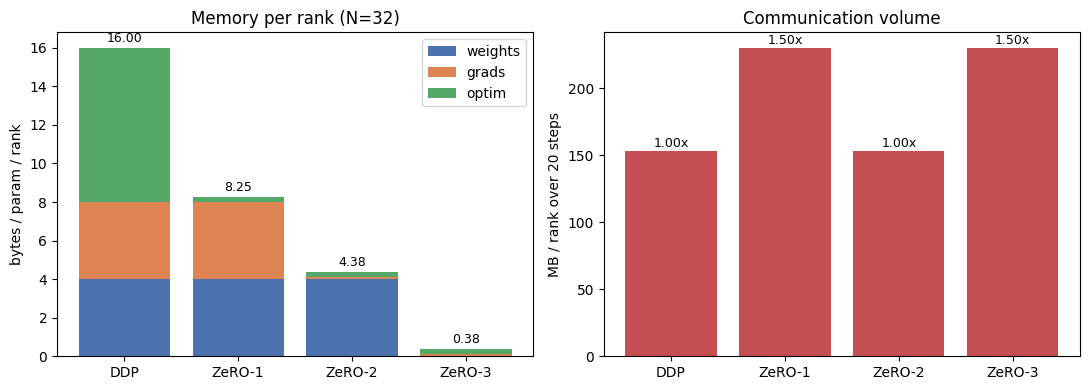

In [23]:
import matplotlib.pyplot as plt

names = [n for n, _ in RUNS]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# Memory, stacked by category
cats, colors = ["weights", "grads", "optim"], ["#4C72B0", "#DD8452", "#55A868"]
bottom = [0.0] * 4
for cat, c in zip(cats, colors):
    vals = []
    for _, run in RUNS:
        m = run["mem"]
        vals.append(m[cat] / P if cat in m else
                    {"weights": 0.125, "grads": 0.125, "optim": 0.25}[cat])
    ax1.bar(names, vals, bottom=bottom, label=cat, color=c)
    bottom = [b + v for b, v in zip(bottom, vals)]
for i, v in enumerate(bottom):
    ax1.text(i, v + 0.3, f"{v:.2f}", ha="center", fontsize=9)
ax1.set_ylabel("bytes / param / rank")
ax1.set_title(f"Memory per rank (N={WORLD_SIZE})")
ax1.legend()

# Communication
comm = [run["log"].total_bytes() / 1e6 for _, run in RUNS]
bars = ax2.bar(names, comm, color="#C44E52")
for b, v in zip(bars, comm):
    ax2.text(b.get_x() + b.get_width()/2, v + 3,
             f"{v/comm[0]:.2f}x", ha="center", fontsize=9)
ax2.set_ylabel(f"MB / rank over {STEPS} steps")
ax2.set_title("Communication volume")

plt.tight_layout()
plt.savefig("zero_results.png", dpi=120)
plt.show()